In [1]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using ReactionMechanismSimulator

  Activating project at `~/miniforge3/envs/rmg_env3/julia_env`
Precompiling packages...
   3912.5 ms  ? DomainSets
   3700.0 ms  ? Symbolics
  11543.8 ms  ? ModelingToolkit
  41431.6 ms  ? SciMLSensitivity
Info Given ReactionMechanismSimulator was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   2982.5 ms  ? ReactionMechanismSimulator
[ Info: Precompiling ReactionMechanismSimulator [c2d78dd2-25c4-5b79-bebc-be6c69dd440f]
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
[ Info: Skipping precompilation since __precompile__(false). Importing ReactionMechanismSimulator [c2d78dd2-25c4-5b79-bebc-be6c69dd440f].
┌ Warning: Replacing docs for `ReactionMechanismSimulator.getpairs :: Tuple{T} where T<:ReactionMechanismSimulator.AbstractReaction` in module `ReactionMechanismSimulator`
└

In [2]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK
using DataFrames
using GlobalSensitivity
using Random
using Statistics

function run_co2_reduction_simulation(params::Vector{Float64})
	try
		CO2_M = params[1]
		pH = params[2]
		surface_phi = params[3]

		rms_file = "/home/danieltori/CO2_RR_RMG/CO2_Reduction_Ag/Ag_C2_042925.rms"

		outdict = readinput(rms_file)
		boundarylayerspcs = outdict["gas"]["Species"]
		boundarylayerrxns = outdict["gas"]["Reactions"]
		surfspcs = outdict["surface"]["Species"]
		surfrxns = outdict["surface"]["Reactions"]
		interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
		solv = outdict["Solvents"][1]

		sitedensity = 2.292e-5; #Ag111
		boundarylayer = IdealDiluteSolution(boundarylayerspcs, boundarylayerrxns, solv,
			name = "boundarylayeruid", diffusionlimited = true)
		surf = IdealSurface(surfspcs, surfrxns, sitedensity, name = "surface")


    C_proton = 10.0^(-pH) * 1e3         # mol/m³
    C_co2    = CO2_M * 1e3              # mol/m³
    C_default = 1e-12
    V_res   = 1e3
		layer_thickness = 1e-6;
    AVratio = 36.0
    A_surf  = V_res * AVratio
    V_bl    = A_surf * layer_thickness
    sites   = sitedensity * A_surf
		

		initialcondsboundarylayer = Dict([
			"proton" => C_proton * V_bl,
			"CO2" => C_co2 * V_bl,
			"V" => V_bl,
			"T" => 300,
			"Phi" => 0.0,
			"d" => 0.0,
		])

		initialcondsreservoir = Dict([
			"proton" => C_proton,
			"CO2" => C_co2,
			"V" => V_res,
			"T" => 300,
		])

		initialcondssurf = Dict([
			"CO2X" => 0.6 * sites,
			"vacantX" => 0.4 * sites,
			"A" => A_surf,
			"T" => 300,
			"Phi" => surface_phi,
		])

		domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(
			phase = boundarylayer, initialconds = initialcondsboundarylayer)
		domaincat, y0cat, pcat = ConstantTAPhiDomain(
			phase = surf, initialconds = initialcondssurf)

		inter, pinter = ReactiveInternalInterfaceConstantTPhi(
			domainboundarylayer, domaincat, interfacerxns, 298.15, A_surf)
		diffusionlayer = ConstantReservoirDiffusion(
			domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness)
		interfaces = [inter, diffusionlayer]

		@time react, y0, p = Reactor((domainboundarylayer, domaincat),
			(y0boundarylayer, y0cat),
			(0.0, 1e3),
			interfaces,
			(pboundarylayer, pcat, pinter))

		@time sol = solve(react.ode, Sundials.CVODE_BDF(), abstol = 1e-20, reltol = 1e-8)

		if sol.retcode != :Success
			return [1e-15, 1e-15, 0.001, 0]
		end

		ssys = SystemSimulation(sol, (domainboundarylayer, domaincat), interfaces, p)

		# EXACT CALCULATION METHOD
		analysis_time = 100
		co2_rate = abs(sum(rops(ssys, "CO2", analysis_time)))

		OCO_rate = abs(sum(rops(ssys, "O=CO", analysis_time)))

		CO2HX_rate = 0.0
		try
			CO2HX_rate = abs(sum(rops(ssys, "CO2HX", analysis_time)))
		catch
			CO2HX_rate = 1e-15
		end

		return [OCO_rate, CO2HX_rate]

	catch e
		return [100, 1e-15]
	end
end

function run_gsa()
	bounds = [ [1e-5, 1e-2], [5, 9], [-0.714, -0.514]]
	param_names = ["CO2_conc", "pH", "surface_potential"]

	# Initialize variables
	morris_result = nothing

	# Morris
	println("Running Morris...")
	try
		morris_result = GlobalSensitivity.gsa(run_co2_reduction_simulation, GlobalSensitivity.Morris(), bounds; N = 200)
		println("Morris completed")
	catch e
		println("Morris failed: $e")
	end

	# Results
	if morris_result !== nothing
		num_outputs = size(morris_result.means_star, 1)
		num_params  = size(morris_result.means_star, 2)

		println("\nMorris Results:")
		for i in 1:num_outputs
			for j in 1:num_params
				#println("$(param_names[j]) -> Output $i: μ* = $(round(morris_result.means_star[i,j], digits=4))")
				println("Output $i  ←  $(param_names[j]) : μ* = $(round(morris_result.means_star[i,j], digits=4))")
			end
		end
	end

	return morris_result
end

morris_result = run_gsa()

Running Morris...


[16:33:09] WARNING: not removing hydrogen atom without neighbors
[16:33:09] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  5.657606 seconds (12.34 M allocations: 801.362 MiB, 4.89% gc time, 99.80% compilation time: <1% of which was recompilation)
  3.909529 seconds (5.21 M allocations: 635.312 MiB, 3.50% gc time, 80.00% compilation time)


[16:33:38] WARNING: not removing hydrogen atom without neighbors
[16:33:38] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004039 seconds (8.46 k allocations: 7.893 MiB)
  0.309929 seconds (493.09 k allocations: 362.669 MiB, 13.83% gc time)


...

  0.005865 seconds (8.46 k allocations: 7.893 MiB)
  0.360465 seconds (464.62 k allocations: 343.442 MiB, 11.14% gc time)


[16:36:00] WARNING: not removing hydrogen atom without neighbors
[16:36:00] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.003860 seconds (8.46 k allocations: 7.893 MiB)
  0.265638 seconds (470.50 k allocations: 344.929 MiB, 5.10% gc time)


[16:36:02] WARNING: not removing hydrogen atom without neighbors
[16:36:02] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.MorrisResult{Matrix{Float64}, Vector{Any}}([2.2898841807892055e-8 2.1091993159363022e-11 -6.355171450740756e-9; -1.7180725408613067e-7 -6.345863897811974e-10 -1.1505232271414846e-8], [2.481545780971274e-8 2.6322068057309775e-11 6.420729136672641e-9; 3.240713254994198e-7 8.992127981324266e-10 2.2614640670414467e-8], [2.2764762867933314e-15 4.3810388566210796e-21 2.653591627273745e-16; 9.815096811866804e-13 3.631269192184147e-18 6.578553699550185e-15], Any[[[-1.4374620013655099e-8, -3.7190892523413857e-6], [6.259855378221346e-10, 8.187540731576595e-10], [6.096534112369125e-10, 7.307709081371838e-10], [3.683094635094993e-13, -6.016833677412934e-14], [1.6678737704802258e-12, 1.719095336277756e-14], [1.5146684536386827e-12, -8.595476682767939e-15], [1.840239906378222e-12, 3.817158448335036e-30], [1.7707514262500098e-12, -2.5786430048303962e-14], [8.940516916351101e-9, 2.820333110884695e-7], [8.611908884717605e-9, 3.4925345322324407e-7], [8.34341614839423e-9, 3.756151033155

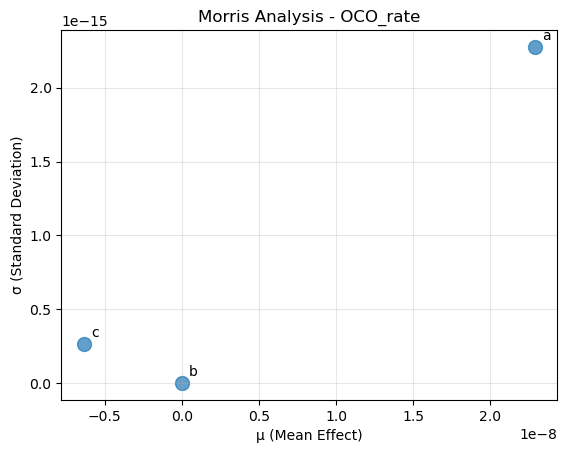

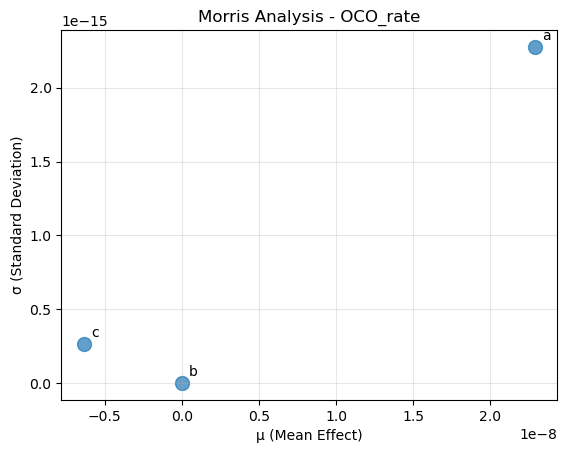

In [3]:
# Correct plotting syntax for PythonPlot
param_labels = ["a", "b", "c"]

# Create Morris signature plot
scatter(morris_result.means[1, :], morris_result.variances[1, :], s = 100, alpha = 0.7)

# Add labels manually
for (i, label) in enumerate(param_labels)
	annotate(label, (morris_result.means[1, i], morris_result.variances[1, i]),
		xytext = (5, 5), textcoords = "offset points")
end

xlabel("μ (Mean Effect)")
ylabel("σ (Standard Deviation)")
title("Morris Analysis - OCO_rate")
grid(true, alpha = 0.3)
gcf()


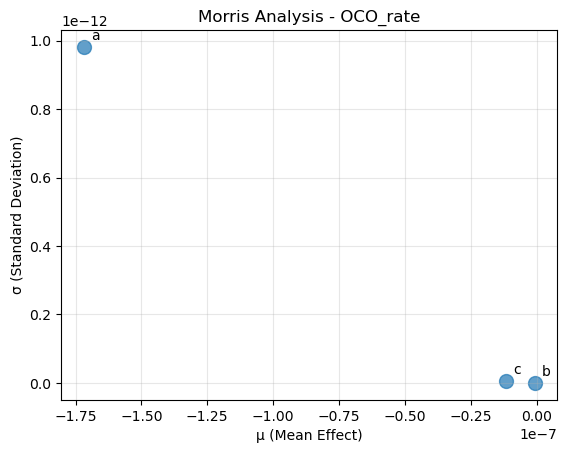

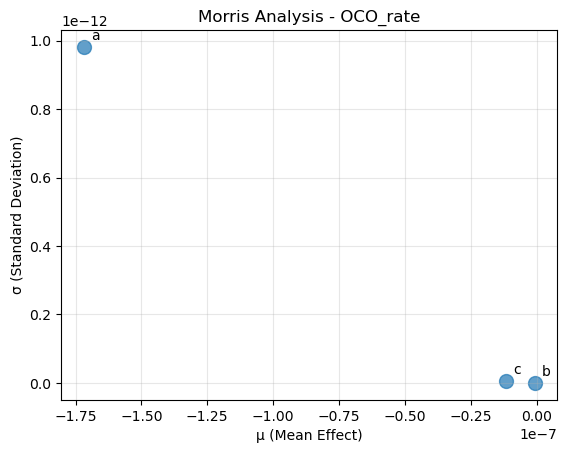

In [4]:
# Correct plotting syntax for PythonPlot
param_labels = ["a", "b", "c"]

# Create Morris signature plot
scatter(morris_result.means[2, :], morris_result.variances[2, :], s = 100, alpha = 0.7)

# Add labels manually
for (i, label) in enumerate(param_labels)
	annotate(label, (morris_result.means[2, i], morris_result.variances[2, i]),
		xytext = (5, 5), textcoords = "offset points")
end

xlabel("μ (Mean Effect)")
ylabel("σ (Standard Deviation)")
title("Morris Analysis - OCO_rate")
grid(true, alpha = 0.3)
gcf()


In [5]:
# Simple readable output for Morris results
param_names = ["CO2_conc", "pH", "surface_potential"]

println("MORRIS RESULTS FOR OCO_RATE:")
for (i, param) in enumerate(param_names)
	mu_star = abs(morris_result.means[1, i])
	sigma = morris_result.variances[1, i]
	importance = mu_star > 0.1 ? "HIGH" : (mu_star > 0.01 ? "MEDIUM" : "LOW")
	println("$param: μ* = $(round(mu_star, digits=6)) ($importance)")
end

MORRIS RESULTS FOR OCO_RATE:
CO2_conc: μ* = 0.0 (LOW)
pH: μ* = 0.0 (LOW)
surface_potential: μ* = 0.0 (LOW)


In [ ]:
# SOBOL GLOBAL SENSITIVITY ANALYSIS
#   - Output 1: OCO_rate      (O=CO, formate rate)
#   - Output 2: CO2HX_rate    (CO2HX pathway)

function run_sobol_gsa()
    bounds = [[1e-5, 1e-2],      # CO2_conc (mol/L)
        [5.0, 9.0],        # pH
        [-0.714, -0.514]   # surface_potential (V)
    ]
    param_names  = ["CO2_conc", "pH", "surface_potential"]
    output_names = ["OCO_rate (O=CO)", "CO2HX_rate"]

    # store results for each output
    sobol_results = Vector{Any}(undef, length(output_names))

    # For reproducibility
    Random.seed!(1234)

    # How many base samples (Sobol will do multiple model evaluations)
    nsamples = 32  

    println("Running Sobol GSA for each output")

    for k in 1:length(output_names)
        println("\n Sobol for output $k: $(output_names[k])")

        # Wrap the model: scalar output = kth component
        model_k(x) = run_co2_reduction_simulation(x)[k]

        # Run Sobol
        sobol_k = GlobalSensitivity.gsa(model_k,
            GlobalSensitivity.Sobol(),
            bounds;
            samples = nsamples
        )

        sobol_results[k] = sobol_k

        # Extract indices
        S1 = sobol_k.S1      # first-order
        ST = sobol_k.ST      # total-order
        S2 = sobol_k.S2      # second-order (interactions)

        println("First-order S1:")
        for j in 1:length(param_names)
            println("  $(param_names[j]) : S1 = $(round(S1[j], digits=4))")
        end

        println("\nTotal-order ST:")
        for j in 1:length(param_names)
            println("  $(param_names[j]) : ST = $(round(ST[j], digits=4))")
        end

        # Plots for this output
        # Bar plot: S1
        clf()
        bar(1:length(param_names), S1)
        xticks(1:length(param_names), param_names, rotation=45, ha="right")
        ylabel("S1")
        title("Sobol S1 for $(output_names[k])")
        tight_layout()
        gcf()

        # Bar plot: ST
        clf()
        bar(1:length(param_names), ST)
        xticks(1:length(param_names), param_names, rotation=45, ha="right")
        ylabel("ST")
        title("Sobol ST for $(output_names[k])")
        tight_layout()
        gcf()

        # Heatmap: S2 (second-order interactions)
        S2_plot = copy(S2)
        # Optionally zero diagonal so we see only cross-interactions
        for i in 1:size(S2_plot, 1)
            S2_plot[i, i] = 0.0
        end

        clf()
        imshow(
            S2_plot,
            origin="lower",
            extent=(0.5, length(param_names)+0.5, 0.5, length(param_names)+0.5),
            aspect="equal"
        )
        colorbar()
        xticks(1:length(param_names), param_names, rotation=45, ha="right")
        yticks(1:length(param_names), param_names)
        title("Sobol S2 interactions for $(output_names[k])")
        tight_layout()
        gcf()
    end

    return sobol_results
end

# Call it:
sobol_results = run_sobol_gsa()

Running Sobol GSA for each output

 Sobol for output 1: OCO_rate (O=CO)


┌ Warning: The `generate_design_matrices(n, d, sampler, R = NoRand(), num_mats)` method does not produces true and independent QMC matrices, see [this doc warning](https://docs.sciml.ai/QuasiMonteCarlo/stable/design_matrix/) for more context. 
│     Prefer using randomization methods such as `R = Shift()`, `R = MatousekScrambling()`, etc., see [documentation](https://docs.sciml.ai/QuasiMonteCarlo/stable/randomization/)
└ @ QuasiMonteCarlo ~/.julia/packages/QuasiMonteCarlo/KvLfb/src/RandomizedQuasiMonteCarlo/iterators.jl:255
[16:59:07] WARNING: not removing hydrogen atom without neighbors
[16:59:07] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate Stoke

  0.004153 seconds (8.46 k allocations: 7.893 MiB)
  0.253013 seconds (444.66 k allocations: 326.170 MiB, 10.97% gc time)


[16:59:13] WARNING: not removing hydrogen atom without neighbors
[16:59:13] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004215 seconds (8.46 k allocations: 7.893 MiB)
  0.248134 seconds (346.94 k allocations: 286.847 MiB, 5.55% gc time)


...

[17:01:31] WARNING: not removing hydrogen atom without neighbors
[17:01:31] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.005120 seconds (8.46 k allocations: 7.882 MiB)
  0.209005 seconds (339.97 k allocations: 281.986 MiB, 12.85% gc time)


[17:01:35] WARNING: not removing hydrogen atom without neighbors
[17:01:35] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004468 seconds (8.46 k allocations: 7.893 MiB)
  0.226159 seconds (430.69 k allocations: 322.858 MiB, 4.54% gc time)


[17:01:41] WARNING: not removing hydrogen atom without neighbors
[17:01:41] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

In [ ]:
# Plot Morris μ*
clf()
bar(["pH", "CO2", "Voltage"], morris_result.mu_star)
ylabel("μ* (Mean absolute elementary effect)")
title("Morris Screening for Formate (O=CO)")
gcf()


In [ ]:
# Plot Morris σ (interaction / nonlinearity indication)
clf()
bar(["pH", "CO2", "Voltage"], morris_result.sigma)
ylabel("σ (Std dev of elementary effects)")
title("Morris σ for Formate (O=CO) – Nonlinearity / Interaction")
gcf()

In [ ]:
# SOBOL SENSITIVITY ANALYSIS (VARIANCE-BASED)
# samples: number of base quasi-random samples.
# Total runs ≈ samples * (2 * n_params + 2)
sobol_samples = 64  # start small; increase later when it's stable

sobol_result = gsa(model_simulation,
                   Sobol(),
                   lb,
                   ub;
                   samples = sobol_samples)

println("\n SOBOL RESULTS (Formate O=CO)")
println("First-order indices S1: ", sobol_result.S1)
println("Total indices    ST: ", sobol_result.ST)
println("Second-order S2 matrix: ")
println(sobol_result.S2)

In [ ]:
# Plot first-order Sobol indices
clf()
bar(["pH", "CO2", "Voltage"], sobol_result.S1)
ylabel("First-order Sobol index S1 (O=CO at t_final)")
title("Sobol Sensitivity for Formate (O=CO)")
gcf()

In [ ]:
# Plot total Sobol indices
clf()
bar(["pH", "CO2", "Voltage"], sobol_result.ST)
ylabel("Total Sobol index ST (O=CO at t_final)")
title("Total Sobol Sensitivity for Formate (O=CO)")
gcf()
